# Deepfake Multimedia Forensic Analysis Report

This interactive notebook is designed to generate automated, AI-driven forensic reports for multimedia deepfake detection. Instead of relying on traditional cybersecurity tools, this methodology strictly leverages our proprietary AI models (`CoAtNet`, `Whisper`, `XGBoost`) to provide interpretable visual proofs.

### Supported Modalities & Proofs:
1. **Image Pipeline:** Error Level Analysis (ELA - representing our 5-channel preprocessing), and Grad-CAM++ (Visualizing CoAtNet's spatial focus).
2. **Audio Pipeline:** Log-Mel Spectrograms (Whisper Features), and Temporal Occlusion Heatmaps (Tracking anomalous frequencies and manipulations).
3. **Video Pipeline:** Modality Contribution Bars (Explaining the 2816-dimensional XGBoost fusion decision), and Spatio-Temporal Probability Timelines (Isolating the exact moment and modality of forgery).

In [1]:
import os
import cv2
import torch
import torch.nn as nn
import librosa
import joblib
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from PIL import Image, ImageChops, ImageEnhance
import warnings
import timm
from transformers import WhisperProcessor, WhisperModel
from tqdm import tqdm

warnings.filterwarnings('ignore')

try:
    from pytorch_grad_cam import ScoreCAM, EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("pytorch_grad_cam not installed. Visualizations will be limited. Run: !pip install grad-cam")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def create_sample_dir(sample_path):
    name = Path(sample_path).stem
    out_dir = Path(f"./Forensic_Reports/{name}")
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


## 1. Core Feature Extractors & Architectures

In [2]:
def compute_ela(image_rgb, quality=90):
    pil_img = Image.fromarray(image_rgb)
    import io
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    compressed = np.array(Image.open(buffer).convert('RGB')).astype(np.float32)
    original = image_rgb.astype(np.float32)
    ela_map = np.abs(original - compressed).mean(axis=2)
    ela_max = ela_map.max()
    if ela_max > 0: ela_map /= ela_max
    return ela_map.astype(np.float32)

def compute_fft_magnitude(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    fft = np.fft.fft2(gray)
    fft_shift = np.fft.fftshift(fft)
    magnitude = np.log1p(np.abs(fft_shift))
    mag_max = magnitude.max()
    if mag_max > 0: magnitude /= mag_max
    return magnitude.astype(np.float32)

def prepare_5ch_tensor(image_rgb, size=224):
    image_rgb_res = cv2.resize(image_rgb, (size, size))
    ela = compute_ela(image_rgb_res)
    fft = compute_fft_magnitude(image_rgb_res)
    ela_u8 = (ela * 255).astype(np.uint8)
    fft_u8 = (fft * 255).astype(np.uint8)
    ch5 = np.concatenate([image_rgb_res, ela_u8[..., np.newaxis], fft_u8[..., np.newaxis]], axis=2)
    tensor = torch.from_numpy(ch5).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406, 0.5, 0.5]).view(5, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225, 0.5, 0.5]).view(5, 1, 1)
    return (tensor - mean) / std

def build_coatnet_5ch(num_classes=1, pretrained=False):
    model = timm.create_model('coatnet_0_rw_224', pretrained=pretrained, num_classes=num_classes)
    original_conv = model.stem.conv1
    new_conv = nn.Conv2d(5, original_conv.out_channels, original_conv.kernel_size,
                         original_conv.stride, original_conv.padding, bias=original_conv.bias is not None)
    model.stem.conv1 = new_conv
    return model

def extract_whisper_feature(audio_array, sr=16000, processor=None, model=None):
    if len(audio_array) < 400: return np.zeros(512, dtype=np.float32)
    inputs = processor(audio_array, sampling_rate=sr, return_tensors="pt")
    input_features = inputs.input_features.to(device)
    with torch.no_grad():
        encoder_outputs = model.encoder(input_features)
        return encoder_outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()


## 2. Model Initialization

In [3]:
print("[SYSTEM] Loading Models into Memory...")

# --- 1. IMAGE MODEL ---
image_model = build_coatnet_5ch(num_classes=1, pretrained=False)
try:
    image_model.load_state_dict(torch.load("models/best_coatnet_5ch.pth", map_location=device))
    image_model.eval().to(device)
    print("✅ Image Model (CoAtNet 5-Channel) Loaded.")
except Exception as e:
    print(f"⚠️ Image Model load failed: {e}")

# --- 2. WHISPER EXTRACTOR ---
try:
    whisper_processor = WhisperProcessor.from_pretrained("openai/whisper-base")
    whisper_model = WhisperModel.from_pretrained("openai/whisper-base").to(device)
    whisper_model.eval()
    print("✅ Audio Feature Extractor (Whisper Base) Loaded.")
except Exception as e:
    print(f"⚠️ Whisper Model load failed: {e}")

# --- 3. AUDIO MODEL ---
try:
    audio_xgb_model = joblib.load("models/xgboost_asvspoof_model.joblib")
    print("✅ Audio Classifier (XGBoost) Loaded.")
except Exception as e:
    print(f"⚠️ Audio Model load failed: {e}")

# --- 4. VIDEO FUSION MODEL ---
try:
    video_fusion_xgb = joblib.load("Final-Vid/xgboost_fusion_model.joblib")
    print("✅ Video Fusion Classifier (XGBoost) Loaded.")
except Exception as e:
    print(f"⚠️ Video Model load failed: {e}")


[SYSTEM] Loading Models into Memory...
✅ Image Model (CoAtNet 5-Channel) Loaded.


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

✅ Audio Feature Extractor (Whisper Base) Loaded.
✅ Audio Classifier (XGBoost) Loaded.
✅ Video Fusion Classifier (XGBoost) Loaded.


## 3. Image Pipeline


[ IMAGE PIPELINE ] Forensic Analysis: 14_conf0.822_img001831.jpg
Generating EigenCAM (Principal Components of Attention)...
Generating ScoreCAM (Gradient-Free Mask Evaluation)...


100%|██████████| 12/12 [00:08<00:00,  1.44it/s]


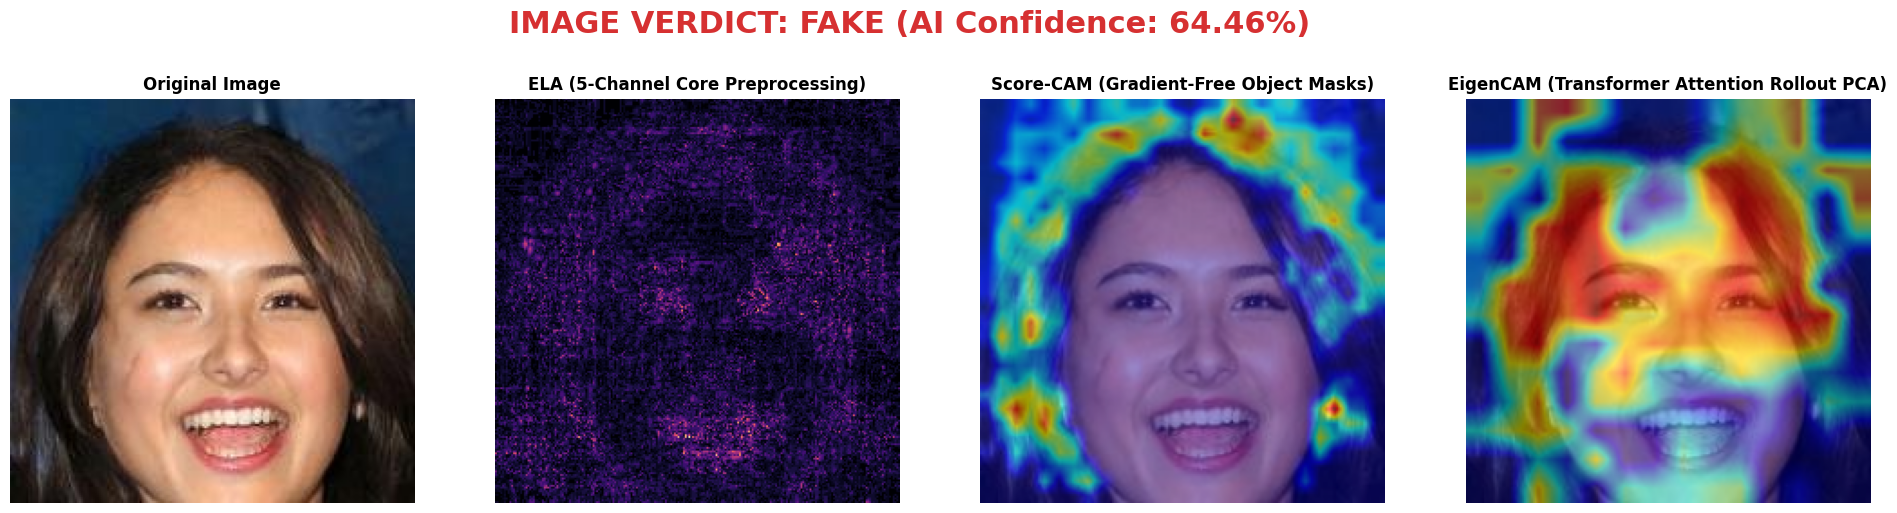


[SUCCESS] Forensic evidence preserved at: Forensic_Reports\14_conf0.822_img001831\image_pipeline_report.png



In [4]:
def generate_eigen_cam(tensor, model):
    try:
        # EigenCAM extracts the Principal Components of the 2D activations.
        # Best targeted at the Transformer stages since it handles multi-head attention natively.
        target_layers = [model.stages[-2]] 
        cam = EigenCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=tensor.unsqueeze(0), targets=None)[0, :]
        return grayscale_cam
    except Exception:
        return np.zeros((224, 224))

def generate_score_cam(tensor, model):
    try:
        # ScoreCAM is gradient-free and uses mask-based activation scoring.
        # Best targeted at the final CNN stage before attention disperses the spatial map.
        target_layers = [model.stages[1]] 
        cam = ScoreCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=tensor.unsqueeze(0), targets=None)[0, :]
        return grayscale_cam
    except Exception:
        return np.zeros((224, 224))

def analyze_image(image_path):
    if not os.path.exists(image_path):
        print(f"[ERROR] File not found: {image_path}"); return
        
    print(f"\n{'='*50}\n[ IMAGE PIPELINE ] Forensic Analysis: {Path(image_path).name}\n{'='*50}")
    out_dir = create_sample_dir(image_path)
    
    image_bgr = cv2.imread(image_path)
    orig_np = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    
    tensor = prepare_5ch_tensor(orig_np).to(device)
    
    with torch.no_grad():
        logits = image_model(tensor.unsqueeze(0))
        fake_prob = torch.sigmoid(logits).item()
        
    verdict = "FAKE" if fake_prob > 0.5 else "REAL"
    
    ela_vis = compute_ela(cv2.resize(orig_np, (224, 224)))
    
    print("Generating EigenCAM (Principal Components of Attention)...")
    eigen_gray = generate_eigen_cam(tensor, image_model)
    print("Generating ScoreCAM (Gradient-Free Mask Evaluation)...")
    score_gray = generate_score_cam(tensor, image_model)
    
    try:
        eigen_vis = show_cam_on_image(cv2.resize(orig_np, (224,224))/255.0, eigen_gray, use_rgb=True)
        score_vis = show_cam_on_image(cv2.resize(orig_np, (224,224))/255.0, score_gray, use_rgb=True)
    except:
        eigen_vis = np.zeros_like(cv2.resize(orig_np, (224,224)))
        score_vis = np.zeros_like(cv2.resize(orig_np, (224,224)))
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    axes[0].imshow(orig_np); axes[0].set_title("Original Image", fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(ela_vis, cmap='magma'); axes[1].set_title("ELA (5-Channel Core Preprocessing)", fontweight='bold'); axes[1].axis('off')
    axes[2].imshow(score_vis); axes[2].set_title("Score-CAM (Gradient-Free Object Masks)", fontweight='bold'); axes[2].axis('off')
    axes[3].imshow(eigen_vis); axes[3].set_title("EigenCAM (Transformer Attention Rollout PCA)", fontweight='bold'); axes[3].axis('off')
    
    title_color = '#d63031' if verdict == 'FAKE' else '#00b894'
    plt.suptitle(f"IMAGE VERDICT: {verdict} (AI Confidence: {fake_prob*100:.2f}%)", fontsize=22, color=title_color, fontweight='heavy')
    
    save_path = out_dir / 'image_pipeline_report.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"\n[SUCCESS] Forensic evidence preserved at: {save_path}\n")

analyze_image("14_conf0.822_img001831.jpg")


## 4. Audio Pipeline


[ AUDIO PIPELINE ] Forensic Analysis: LA_T_2826716.flac
Generating Temporal Occlusion Heatmap...


Processing Audio Segments: 100%|██████████| 15/15 [00:07<00:00,  1.96it/s]


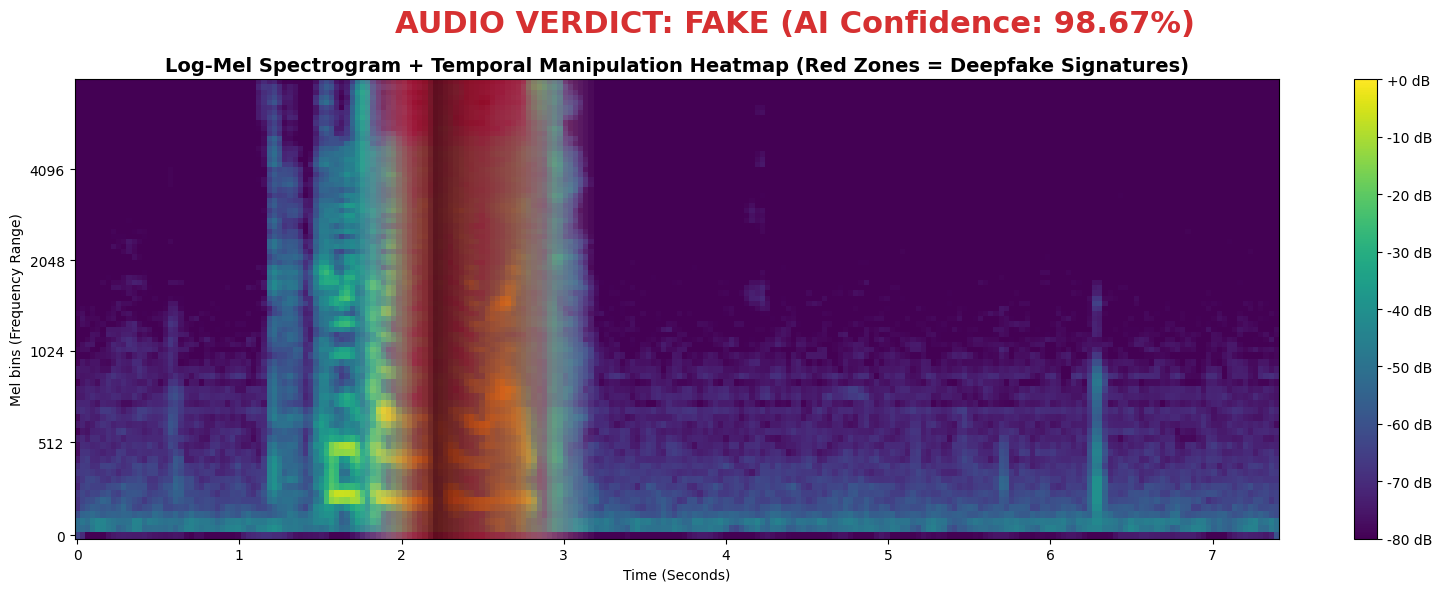


[SUCCESS] Forensic evidence preserved at: Forensic_Reports\LA_T_2826716\audio_pipeline_report.png



In [7]:
def analyze_audio(audio_path):
    if not os.path.exists(audio_path):
        print(f"[ERROR] File not found: {audio_path}"); return

    print(f"\n{'='*50}\n[ AUDIO PIPELINE ] Forensic Analysis: {Path(audio_path).name}\n{'='*50}")
    out_dir = create_sample_dir(audio_path)
        
    y, sr = librosa.load(audio_path, sr=16000)
    
    # Base Inference
    base_feat = extract_whisper_feature(y, sr, whisper_processor, whisper_model)
    fake_prob = audio_xgb_model.predict_proba(base_feat.reshape(1, -1))[0, 1]
    verdict = "FAKE" if fake_prob > 0.5 else "REAL"
    
    # Temporal Occlusion Analysis
    segment_duration = 0.5
    times = np.arange(0, librosa.get_duration(y=y, sr=sr), segment_duration)
    importance = []
    
    print("Generating Temporal Occlusion Heatmap...")
    for t in tqdm(times, desc="Processing Audio Segments"):
        start_sample = int(t * sr)
        end_sample = int((t + segment_duration) * sr)
        y_occ = y.copy()
        y_occ[start_sample:end_sample] = 0
        
        occ_feat = extract_whisper_feature(y_occ, sr, whisper_processor, whisper_model)
        occ_prob = audio_xgb_model.predict_proba(occ_feat.reshape(1, -1))[0, 1]
        
        drop = fake_prob - occ_prob
        importance.append(max(0, drop))
        
    importance = np.array(importance)
    if importance.max() > 0: importance = importance / importance.max()
    
    # Visualization (Overlaying Heatmap perfectly on Spectrogram)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Create a custom colormap for the Heatmap: Solid red but fades to transparent for zeros
    cmap_reds = plt.cm.Reds(np.arange(plt.cm.Reds.N))
    cmap_reds[:,-1] = np.linspace(0.0, 0.85, plt.cm.Reds.N) # Alpha channel
    custom_reds = mcolors.ListedColormap(cmap_reds)
    
    # Resize importance exactly to the spectrogram matrix size for perfect alignment
    imp_2d = np.tile(importance.reshape(1, -1), (mel_db.shape[0], 1))
    importance_resized = cv2.resize(imp_2d, (mel_db.shape[1], mel_db.shape[0]), interpolation=cv2.INTER_LINEAR)
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Draw base spectrogram
    img = librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', sr=sr, ax=ax, fmax=8000, cmap='viridis')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    
    # Draw transparent heatmap ON TOP of the spectrogram
    librosa.display.specshow(importance_resized, x_axis='time', y_axis='mel', sr=sr, ax=ax, fmax=8000, cmap=custom_reds)
    
    ax.set_title('Log-Mel Spectrogram + Temporal Manipulation Heatmap (Red Zones = Deepfake Signatures)', fontweight='bold', fontsize=14)
    ax.set_xlabel('Time (Seconds)')
    ax.set_ylabel('Mel bins (Frequency Range)')
    
    title_color = '#d63031' if verdict == 'FAKE' else '#00b894'
    plt.suptitle(f"AUDIO VERDICT: {verdict} (AI Confidence: {fake_prob*100:.2f}%)", fontsize=22, color=title_color, fontweight='heavy')
    
    plt.tight_layout()
    save_path = out_dir / 'audio_pipeline_report.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"\n[SUCCESS] Forensic evidence preserved at: {save_path}\n")

analyze_audio("LA_T_2826716.flac")


## 5. Video Pipeline


[ VIDEO PIPELINE ] Forensic Analysis: 124_Fake_id01036_00010_id01544_uBo9585VW2A_id02268_wavtolip.mp4
Generating Spatio-Temporal Timeline & Visual Evidence...


Scanning Video Timeline: 100%|██████████| 6/6 [00:00<00:00,  8.50it/s]


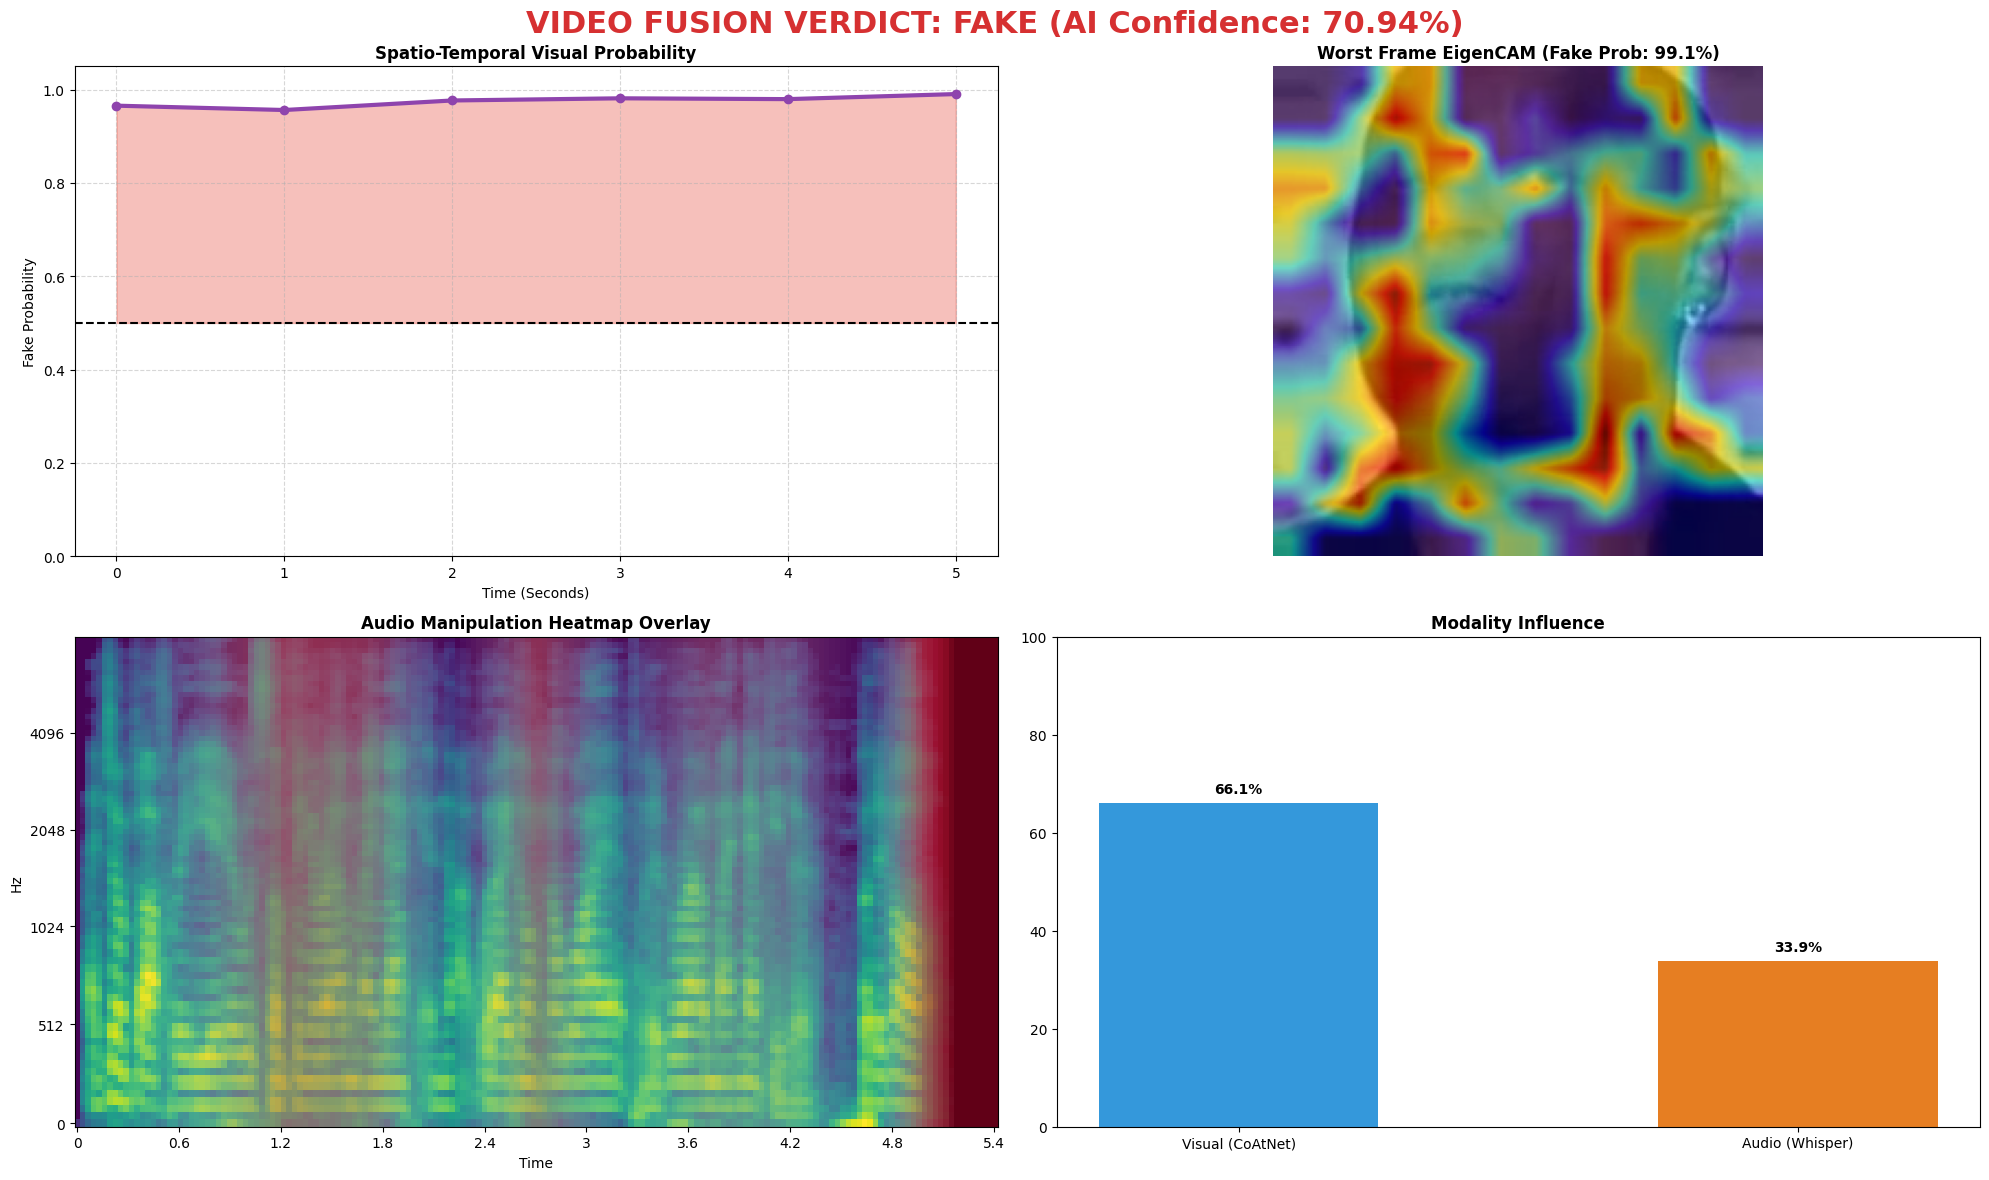


[SUCCESS] Forensic evidence preserved at: Forensic_Reports\124_Fake_id01036_00010_id01544_uBo9585VW2A_id02268_wavtolip\video_pipeline_report.png


In [8]:
def analyze_video(video_path):
    if not os.path.exists(video_path):
        print(f"[ERROR] File not found: {video_path}"); return

    print(f"\n{'='*50}\n[ VIDEO PIPELINE ] Forensic Analysis: {Path(video_path).name}\n{'='*50}")
    out_dir = create_sample_dir(video_path)
    
    # 1. Extract Frames
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret or len(frames) > 300: break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    
    if len(frames) == 0:
        print("[ERROR] No frames extracted."); return

    # 2. Extract Audio
    import subprocess
    tmp_wav = out_dir / "temp_audio.wav"
    subprocess.run(['ffmpeg', '-y', '-v', 'error', '-i', video_path, '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', str(tmp_wav)])
    y, sr = np.zeros(16000), 16000
    if tmp_wav.exists():
        y, sr = librosa.load(str(tmp_wav), sr=16000)
        tmp_wav.unlink()
        
    # 3. Fusion Representation
    num_frames_target = 5
    idx = np.linspace(0, len(frames)-1, min(len(frames), num_frames_target), dtype=int)
    sampled_frames = [frames[i] for i in idx]
    while len(sampled_frames) < num_frames_target:
        sampled_frames.append(sampled_frames[-1])
        
    coatnet_features = {}
    def hook(m, i, o): coatnet_features['emb'] = o.detach()
    handle = image_model.head.global_pool.register_forward_hook(hook)
    
    frame_embs = []
    for f in sampled_frames:
        t = prepare_5ch_tensor(f).unsqueeze(0).to(device)
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                image_model(t)
        frame_embs.append(coatnet_features['emb'].squeeze().cpu().numpy())
    handle.remove()
    
    frame_embs = np.array(frame_embs)
    video_vec = np.concatenate([frame_embs.mean(0), frame_embs.max(0), frame_embs.std(0)])
    audio_vec = extract_whisper_feature(y, sr, whisper_processor, whisper_model)
    
    fused_vec = np.concatenate([video_vec, audio_vec]).reshape(1, -1)
    final_prob = video_fusion_xgb.predict_proba(fused_vec)[0, 1]
    verdict = "FAKE" if final_prob > 0.5 else "REAL"
    
    # 4. Modality Contribution
    imps = video_fusion_xgb.feature_importances_
    visual_contrib = np.sum(imps[:2304])
    audio_contrib = np.sum(imps[2304:])
    tot = visual_contrib + audio_contrib if (visual_contrib + audio_contrib) > 0 else 1
    
    # 5. Timeline Generation & Finding Worst Frame
    time_steps = []
    visual_probs = []
    max_prob = -1
    worst_frame = None
    worst_tensor = None
    
    print("Generating Spatio-Temporal Timeline & Visual Evidence...")
    for i in tqdm(range(0, len(frames), int(fps)), desc="Scanning Video Timeline"):
        f = frames[i]
        t = prepare_5ch_tensor(f).unsqueeze(0).to(device)
        with torch.no_grad():
            prob = torch.sigmoid(image_model(t)).item()
        visual_probs.append(prob)
        time_steps.append(i / fps)
        if prob > max_prob:
            max_prob = prob
            worst_frame = f
            worst_tensor = t
            
    # 6. EigenCAM for Worst Frame
    eigen_gray = generate_eigen_cam(worst_tensor.squeeze(0), image_model)
    try:
        worst_cam = show_cam_on_image(cv2.resize(worst_frame, (224,224))/255.0, eigen_gray, use_rgb=True)
    except:
        worst_cam = cv2.resize(worst_frame, (224,224))
        
    # Visualization (4-Panel Dashboard)
    fig = plt.figure(figsize=(20, 12))
    ax1 = plt.subplot(2, 2, 1) # Timeline
    ax2 = plt.subplot(2, 2, 2) # Worst Frame EigenCAM
    ax3 = plt.subplot(2, 2, 3) # Spectrogram with heatmap
    ax4 = plt.subplot(2, 2, 4) # Bar chart
    
    # Ax1: Timeline
    ax1.plot(time_steps, visual_probs, marker='o', color='#8e44ad', linewidth=3, markersize=6)
    ax1.fill_between(time_steps, visual_probs, 0.5, where=(np.array(visual_probs) >= 0.5), color='#e74c3c', alpha=0.35, interpolate=True)
    ax1.axhline(y=0.5, color='black', linestyle='--', label='Detection Threshold')
    ax1.set_title('Spatio-Temporal Visual Probability', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Time (Seconds)'); ax1.set_ylabel('Fake Probability')
    ax1.set_ylim([0, 1.05]); ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Ax2: Worst Frame
    ax2.imshow(worst_cam)
    ax2.set_title(f'Worst Frame EigenCAM (Fake Prob: {max_prob*100:.1f}%)', fontweight='bold', fontsize=12)
    ax2.axis('off')
    
    # Ax3: Audio Spectrogram
    if librosa.get_duration(y=y, sr=sr) > 0:
        segment_duration = 0.5
        times = np.arange(0, librosa.get_duration(y=y, sr=sr), segment_duration)
        importance = []
        base_audio_prob = audio_xgb_model.predict_proba(audio_vec.reshape(1,-1))[0, 1]
        for t_sec in times:
            s_samp = int(t_sec * sr)
            e_samp = int((t_sec + segment_duration) * sr)
            y_occ = y.copy()
            y_occ[s_samp:e_samp] = 0
            occ_feat = extract_whisper_feature(y_occ, sr, whisper_processor, whisper_model)
            occ_prob = audio_xgb_model.predict_proba(occ_feat.reshape(1, -1))[0, 1]
            importance.append(max(0, base_audio_prob - occ_prob))
        importance = np.array(importance)
        if importance.max() > 0: importance /= importance.max()
        
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(mel_db, x_axis='time', y_axis='mel', sr=sr, ax=ax3, fmax=8000, cmap='viridis')
        
        cmap_reds = plt.cm.Reds(np.arange(plt.cm.Reds.N))
        cmap_reds[:,-1] = np.linspace(0.0, 0.85, plt.cm.Reds.N)
        custom_reds = mcolors.ListedColormap(cmap_reds)
        imp_2d = np.tile(importance.reshape(1, -1), (mel_db.shape[0], 1))
        importance_resized = cv2.resize(imp_2d, (mel_db.shape[1], mel_db.shape[0]), interpolation=cv2.INTER_LINEAR)
        librosa.display.specshow(importance_resized, x_axis='time', y_axis='mel', sr=sr, ax=ax3, fmax=8000, cmap=custom_reds)
    ax3.set_title('Audio Manipulation Heatmap Overlay', fontweight='bold', fontsize=12)
    
    # Ax4: Contributions
    labels = ['Visual (CoAtNet)', 'Audio (Whisper)']
    sizes = [(visual_contrib/tot)*100, (audio_contrib/tot)*100]
    bars = ax4.bar(labels, sizes, color=['#3498db', '#e67e22'], width=0.5)
    ax4.set_title('Modality Influence', fontweight='bold', fontsize=12)
    ax4.set_ylim([0, 100])
    for bar in bars:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha='center', fontweight='bold')
        
    title_color = '#d63031' if verdict == 'FAKE' else '#00b894'
    plt.suptitle(f"VIDEO FUSION VERDICT: {verdict} (AI Confidence: {final_prob*100:.2f}%)", fontsize=22, color=title_color, fontweight='heavy')
    
    plt.tight_layout()
    save_path = out_dir / 'video_pipeline_report.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"\n[SUCCESS] Forensic evidence preserved at: {save_path}")

analyze_video("124_Fake_id01036_00010_id01544_uBo9585VW2A_id02268_wavtolip.mp4")
